In [1]:
print("hello residual")

hello residual


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/fer2013.tar.gz
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/example_submission.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/test.csv


In [15]:
!pip install kaggle==1.5.16

In [16]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [17]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
replace example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [3]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam, SGD, RMSprop # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [4]:
train_df = pd.read_csv("/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/test.csv")

In [5]:
x_train = np.array([
    list(map(int, row.split()))
    for row in train_df['pixels']
]).reshape(-1, 48, 48)

y_train = train_df['emotion'].values

In [6]:
from sklearn.model_selection import train_test_split

x_train = x_train / 255.0
x_train = x_train.reshape(-1, 1, 48, 48)

X_train, X_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (22967, 1, 48, 48)
Val shape: (5742, 1, 48, 48)


In [7]:
class FERDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_dataset = FERDataset(X_train, y_train)
val_dataset   = FERDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.25):
        super(ResidualBlock, self).__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
        )

        # Shortcut connection — if channels change, use 1x1 conv to match dimensions
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels)
        ) if in_channels != out_channels else nn.Identity()

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout2d(dropout_rate)

    def forward(self, x):
        residual = self.shortcut(x)   # ← skip connection
        out = self.conv_block(x)
        out = out + residual          # ← add input back to output
        out = self.relu(out)
        out = self.dropout(out)
        return out

In [ ]:
class ResNetCNN(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super(ResNetCNN, self).__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.block1 = nn.Sequential(
            ResidualBlock(64, 64, dropout_rate),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            ResidualBlock(64, 128, dropout_rate),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            ResidualBlock(128, 256, dropout_rate),
            ResidualBlock(256, 256, dropout_rate),  # ← extra residual same channels
            nn.MaxPool2d(2, 2)
        )

        self.block4 = nn.Sequential(
            ResidualBlock(256, 512, dropout_rate),
            nn.MaxPool2d(2, 2)
        )

        # Classifier
        self.fc = nn.Sequential(
            nn.Flatten(),               
            nn.Linear(512 * 3 * 3, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        x = self.initial(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.fc(x)
        return x

# Sanity check
model = ResNetCNN().to(device)
print(model)

dummy = torch.randn(1, 1, 48, 48).to(device)
print("Output shape:", model(dummy).shape)  # should be torch.Size([1, 7])

ResNetCNN(
  (initial): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (block1): Sequential(
    (0): ResidualBlock(
      (conv_block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Identity()
      (relu): ReLU()
      (dropout): Dropout2d(p=0.25, inplace=False)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): ResidualBlock(
      (conv_block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride

In [10]:
from torchvision import transforms
from torch.utils.data import Dataset

class FERDatasetAugmented(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.augment = augment

        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.1, 0.1)   # slight shift
            ),
        ]) if augment else None

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32)
        if self.augment and self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Augmented dataset only for training, not validation
train_dataset_aug = FERDatasetAugmented(X_train, y_train, augment=True)
val_dataset_aug   = FERDatasetAugmented(X_val, y_val, augment=False)

In [11]:
!pip install wandb -q
import wandb
wandb.login()  # will prompt for API key

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ikvas22 (ikvas22-free-university-of-tbilisi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

[resnet-cnn-adam-lr0.001-drop0.25] Epoch 1/50 | Train Loss: 1.8322 Acc: 0.2359 | Val Loss: 1.7946 Acc: 0.2562 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.25] Epoch 2/50 | Train Loss: 1.7999 Acc: 0.2564 | Val Loss: 1.7515 Acc: 0.3011 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.25] Epoch 3/50 | Train Loss: 1.7338 Acc: 0.2930 | Val Loss: 1.6622 Acc: 0.3434 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.25] Epoch 4/50 | Train Loss: 1.6114 Acc: 0.3621 | Val Loss: 1.6139 Acc: 0.3657 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.25] Epoch 5/50 | Train Loss: 1.5366 Acc: 0.3894 | Val Loss: 1.4880 Acc: 0.4471 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.25] Epoch 6/50 | Train Loss: 1.4974 Acc: 0.4101 | Val Loss: 1.4201 Acc: 0.4420 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.25] Epoch 7/50 | Train Loss: 1.4567 Acc: 0.4262 | Val Loss: 1.3770 Acc: 0.4596 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.25] Epoch 8/50 | Train Loss: 1.4265 Acc: 0.4365 | Val Loss: 1.3402 Acc: 0.4848 | LR: 0.001000


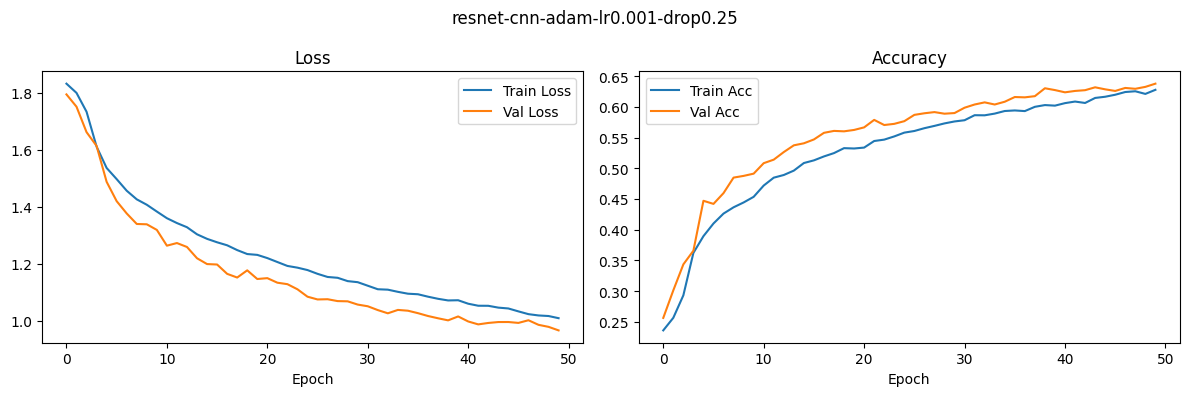

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▁▂▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████
train/loss,██▇▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val/accuracy,▁▂▃▃▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
val/loss,██▇▆▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.63793
best_val_loss,0.96698
epoch,50
final_train_accuracy,0.6279
learning_rate,0.001



✅ Finished: resnet-cnn-adam-lr0.001-drop0.25



[resnet-cnn-adam-lr0.0001-drop0.25] Epoch 1/50 | Train Loss: 1.8295 Acc: 0.2307 | Val Loss: 1.7909 Acc: 0.2612 | LR: 0.000100
[resnet-cnn-adam-lr0.0001-drop0.25] Epoch 2/50 | Train Loss: 1.8027 Acc: 0.2449 | Val Loss: 1.7573 Acc: 0.2715 | LR: 0.000100
[resnet-cnn-adam-lr0.0001-drop0.25] Epoch 3/50 | Train Loss: 1.7667 Acc: 0.2694 | Val Loss: 1.6300 Acc: 0.3436 | LR: 0.000100
[resnet-cnn-adam-lr0.0001-drop0.25] Epoch 4/50 | Train Loss: 1.6123 Acc: 0.3631 | Val Loss: 1.4382 Acc: 0.4478 | LR: 0.000100
[resnet-cnn-adam-lr0.0001-drop0.25] Epoch 5/50 | Train Loss: 1.5122 Acc: 0.4064 | Val Loss: 1.4097 Acc: 0.4565 | LR: 0.000100
[resnet-cnn-adam-lr0.0001-drop0.25] Epoch 6/50 | Train Loss: 1.4447 Acc: 0.4366 | Val Loss: 1.3460 Acc: 0.4704 | LR: 0.000100
[resnet-cnn-adam-lr0.0001-drop0.25] Epoch 7/50 | Train Loss: 1.3933 Acc: 0.4547 | Val Loss: 1.2695 Acc: 0.5054 | LR: 0.000100
[resnet-cnn-adam-lr0.0001-drop0.25] Epoch 8/50 | Train Loss: 1.3608 Acc: 0.4725 | Val Loss: 1.2645 Acc: 0.5125 | LR: 0

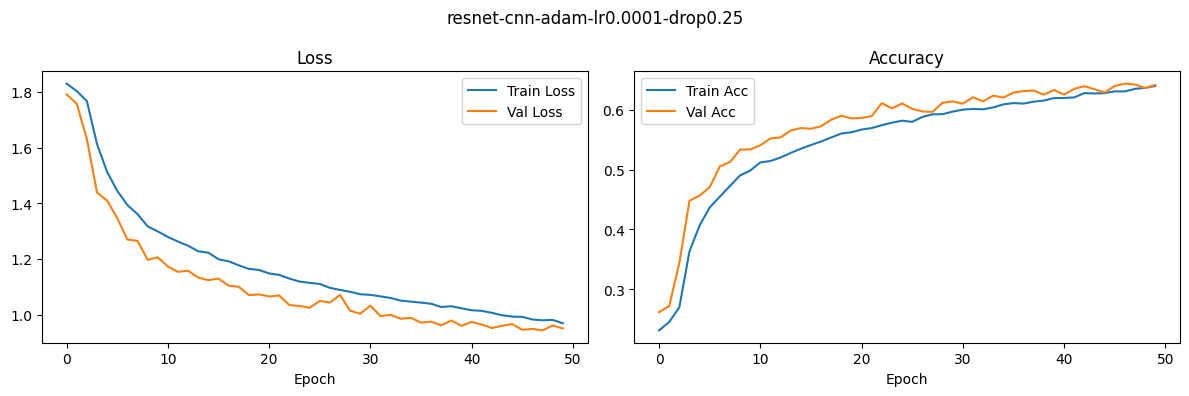

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▁▂▃▄▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇██████████
train/loss,██▇▆▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
val/loss,██▇▅▅▄▄▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.64385
best_val_loss,0.94304
epoch,50
final_train_accuracy,0.63987
learning_rate,0.0001



✅ Finished: resnet-cnn-adam-lr0.0001-drop0.25



[resnet-cnn-adam-lr0.001-drop0.5] Epoch 1/50 | Train Loss: 1.8464 Acc: 0.2337 | Val Loss: 1.8169 Acc: 0.2562 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.5] Epoch 2/50 | Train Loss: 1.8229 Acc: 0.2495 | Val Loss: 1.8061 Acc: 0.2562 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.5] Epoch 3/50 | Train Loss: 1.8225 Acc: 0.2490 | Val Loss: 1.8033 Acc: 0.2562 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.5] Epoch 4/50 | Train Loss: 1.8171 Acc: 0.2497 | Val Loss: 1.7942 Acc: 0.2562 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.5] Epoch 5/50 | Train Loss: 1.8113 Acc: 0.2487 | Val Loss: 1.7929 Acc: 0.2562 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.5] Epoch 6/50 | Train Loss: 1.8052 Acc: 0.2490 | Val Loss: 1.7947 Acc: 0.2562 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.5] Epoch 7/50 | Train Loss: 1.8018 Acc: 0.2507 | Val Loss: 1.7919 Acc: 0.2581 | LR: 0.001000
[resnet-cnn-adam-lr0.001-drop0.5] Epoch 8/50 | Train Loss: 1.7973 Acc: 0.2527 | Val Loss: 1.7672 Acc: 0.2562 | LR: 0.001000
[resnet-

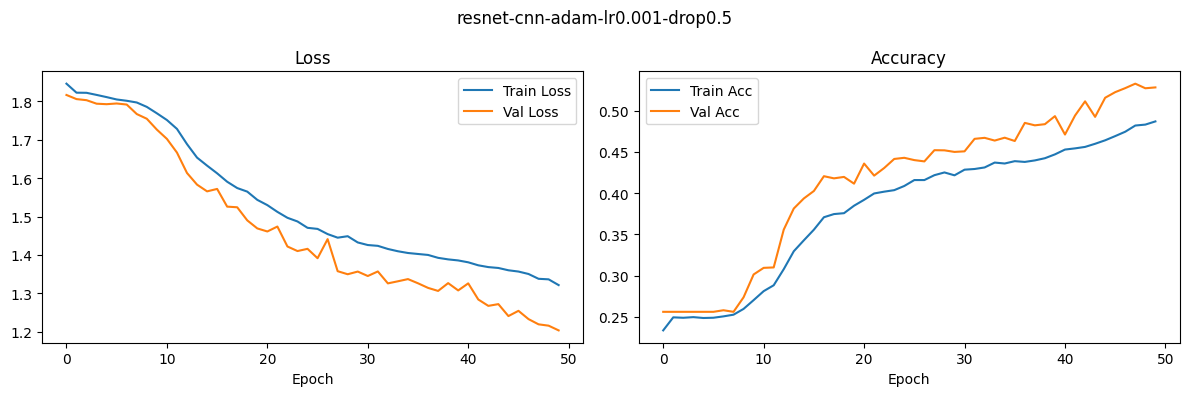

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▁▁▁▁▁▂▂▂▂▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███
train/loss,████▇▇▇▇▇▆▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁
val/accuracy,▁▁▁▁▁▁▁▂▂▄▄▅▅▅▅▆▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▆▇▇█████
val/loss,██████▇▇▇▇▆▅▅▅▅▄▄▄▃▃▃▄▃▃▃▃▂▂▃▂▂▂▂▂▂▁▂▁▁▁
best_val_accuracy,0.53274
best_val_loss,1.20322
epoch,50
final_train_accuracy,0.487
learning_rate,0.001



✅ Finished: resnet-cnn-adam-lr0.001-drop0.5



[resnet-cnn-adam-batch32-drop0.25] Epoch 1/50 | Train Loss: 1.8278 Acc: 0.2431 | Val Loss: 1.7922 Acc: 0.2562 | LR: 0.001000
[resnet-cnn-adam-batch32-drop0.25] Epoch 2/50 | Train Loss: 1.8080 Acc: 0.2509 | Val Loss: 1.7784 Acc: 0.2565 | LR: 0.001000
[resnet-cnn-adam-batch32-drop0.25] Epoch 3/50 | Train Loss: 1.7889 Acc: 0.2638 | Val Loss: 1.7310 Acc: 0.2919 | LR: 0.001000
[resnet-cnn-adam-batch32-drop0.25] Epoch 4/50 | Train Loss: 1.7041 Acc: 0.3020 | Val Loss: 1.5677 Acc: 0.3828 | LR: 0.001000
[resnet-cnn-adam-batch32-drop0.25] Epoch 5/50 | Train Loss: 1.6123 Acc: 0.3552 | Val Loss: 1.5510 Acc: 0.4056 | LR: 0.001000
[resnet-cnn-adam-batch32-drop0.25] Epoch 6/50 | Train Loss: 1.5554 Acc: 0.3849 | Val Loss: 1.4760 Acc: 0.4345 | LR: 0.001000
[resnet-cnn-adam-batch32-drop0.25] Epoch 7/50 | Train Loss: 1.5127 Acc: 0.3986 | Val Loss: 1.4358 Acc: 0.4403 | LR: 0.001000
[resnet-cnn-adam-batch32-drop0.25] Epoch 8/50 | Train Loss: 1.4819 Acc: 0.4102 | Val Loss: 1.4084 Acc: 0.4429 | LR: 0.001000


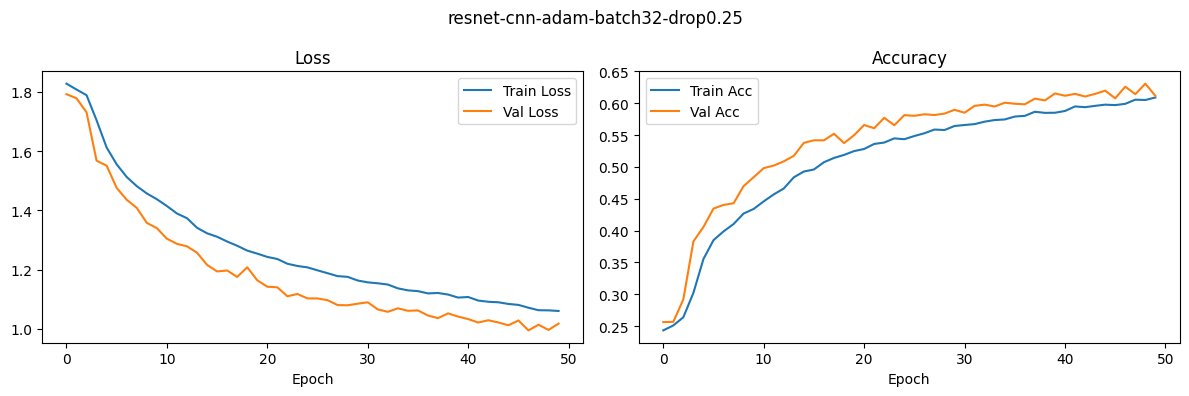

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▁▁▂▃▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train/loss,██▇▆▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/accuracy,▁▁▂▃▄▄▅▅▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
val/loss,██▇▆▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.63079
best_val_loss,0.99489
epoch,50
final_train_accuracy,0.60909
learning_rate,0.001



✅ Finished: resnet-cnn-adam-batch32-drop0.25



[resnet-cnn-adam-noaug-drop0.25] Epoch 1/50 | Train Loss: 1.8288 Acc: 0.2342 | Val Loss: 1.7763 Acc: 0.2604 | LR: 0.001000
[resnet-cnn-adam-noaug-drop0.25] Epoch 2/50 | Train Loss: 1.7973 Acc: 0.2622 | Val Loss: 1.7692 Acc: 0.2658 | LR: 0.001000
[resnet-cnn-adam-noaug-drop0.25] Epoch 3/50 | Train Loss: 1.7180 Acc: 0.3010 | Val Loss: 1.5760 Acc: 0.3584 | LR: 0.001000
[resnet-cnn-adam-noaug-drop0.25] Epoch 4/50 | Train Loss: 1.5863 Acc: 0.3623 | Val Loss: 1.4836 Acc: 0.4117 | LR: 0.001000
[resnet-cnn-adam-noaug-drop0.25] Epoch 5/50 | Train Loss: 1.4951 Acc: 0.4081 | Val Loss: 1.4530 Acc: 0.4380 | LR: 0.001000
[resnet-cnn-adam-noaug-drop0.25] Epoch 6/50 | Train Loss: 1.4427 Acc: 0.4248 | Val Loss: 1.3727 Acc: 0.4425 | LR: 0.001000
[resnet-cnn-adam-noaug-drop0.25] Epoch 7/50 | Train Loss: 1.4046 Acc: 0.4384 | Val Loss: 1.3460 Acc: 0.4704 | LR: 0.001000
[resnet-cnn-adam-noaug-drop0.25] Epoch 8/50 | Train Loss: 1.3778 Acc: 0.4535 | Val Loss: 1.3381 Acc: 0.4737 | LR: 0.001000
[resnet-cnn-adam

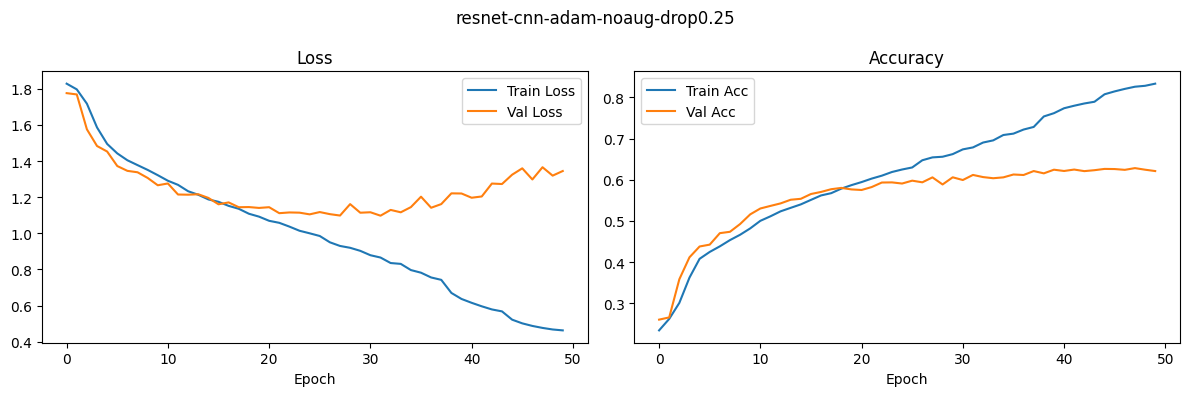

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,██████████████████████████████▄▄▄▄▄▂▂▂▂▁
train/accuracy,▁▁▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████
train/loss,██▇▇▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
val/accuracy,▁▁▃▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇████████████████
val/loss,██▆▅▅▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▂▂▂▂▂▃▃▄▃▄▄
best_val_accuracy,0.62835
best_val_loss,1.09764
epoch,50
final_train_accuracy,0.83346
learning_rate,0.00013



✅ Finished: resnet-cnn-adam-noaug-drop0.25



In [12]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

experiments = [
    {
        "name": "resnet-cnn-adam-lr0.001-drop0.25",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 50,
        "dropout_rate": 0.25,
        "augment": True,
    },
    {
        "name": "resnet-cnn-adam-lr0.0001-drop0.25",
        "learning_rate": 0.0001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 50,
        "dropout_rate": 0.25,
        "augment": True,
    },
    {
        "name": "resnet-cnn-adam-lr0.001-drop0.5",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 50,
        "dropout_rate": 0.5,
        "augment": True,
    },
    {
        "name": "resnet-cnn-adam-batch32-drop0.25",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 32,
        "epochs": 50,
        "dropout_rate": 0.25,
        "augment": True,
    },
    {
        "name": "resnet-cnn-adam-noaug-drop0.25",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 50,
        "dropout_rate": 0.25,
        "augment": False,              # compare with/without augmentation
    },
]

def get_optimizer(name, model, lr):
    if name == "Adam":
        return Adam(model.parameters(), lr=lr)
    elif name == "SGD":
        return SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "RMSprop":
        return RMSprop(model.parameters(), lr=lr)

def run_experiment(config):
    run = wandb.init(
        project="Facial_Expression_Recognition",
        name=config["name"],
        group="resnet-cnn",            # ← separate group from deep-cnn
        tags=["resnet-cnn", "residual", "batchnorm", "dropout", config["optimizer"].lower()],
        config={
            **config,
            "architecture": "ResNetCNN",
            "num_conv_blocks": 4,
            "conv_filters": [64, 128, 256, 512],
            "fc_units": [1024, 512, 128],
            "residual_connections": True,
            "batch_norm": True,
            "dataset": "FER2013"
        }
    )

    model = ResNetCNN(dropout_rate=config["dropout_rate"]).to(device)
    optimizer = get_optimizer(config["optimizer"], model, config["learning_rate"])
    criterion = nn.CrossEntropyLoss()

    scheduler = ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    train_dataset_run = FERDatasetAugmented(X_train, y_train, augment=config["augment"])
    val_dataset_run   = FERDatasetAugmented(X_val, y_val, augment=False)

    train_loader = DataLoader(train_dataset_run, batch_size=config["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_dataset_run, batch_size=config["batch_size"], shuffle=False)

    wandb.watch(model, log="all", log_freq=10)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(config["epochs"]):
        # --- Train ---
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        # --- Validate ---
        model.eval()
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_loss = total_loss / len(val_loader)
        val_acc  = correct / total

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": train_loss,
            "train/accuracy": train_acc,
            "val/loss": val_loss,
            "val/accuracy": val_acc,
            "learning_rate": current_lr,
        })

        print(f"[{config['name']}] Epoch {epoch+1}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"LR: {current_lr:.6f}")

    # --- Plot & Log ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(config["name"])

    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    wandb.log({"training_curves": wandb.Image(fig)})
    plt.show()
    plt.close(fig)

    wandb.summary["best_val_accuracy"]    = max(val_accs)
    wandb.summary["best_val_loss"]        = min(val_losses)
    wandb.summary["final_train_accuracy"] = train_accs[-1]
    wandb.summary["overfit_gap"]          = train_accs[-1] - val_accs[-1]

    wandb.finish()
    print(f"\n✅ Finished: {config['name']}\n{'='*60}\n")

for config in experiments:
    run_experiment(config)